<a href="https://colab.research.google.com/github/likitha888/java-projects/blob/main/GEN_ai_ASS2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms # imports the module, not specific objects from it
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


# Load CIFAR-10 dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]) # Using transforms.<object> now that the module has been imported

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True)

100%|██████████| 170M/170M [00:03<00:00, 43.2MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data


In [ ]:
class Generator(nn.Module):
    def __init__(self, z_dim, num_classes, img_channels=3, hidden_dim=128):
        super(Generator, self).__init__()

        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.model = nn.Sequential(
            nn.Linear(z_dim + num_classes, hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, img_channels * 32 * 32),
            nn.Tanh()  # Output the image in range [-1, 1]
        )

    def forward(self, z, labels):
        label_embedding = self.label_emb(labels)
        x = torch.cat([z, label_embedding], dim=1)
        img = self.model(x)
        img = img.view(img.shape[0], 3, 32, 32)
        return img


In [ ]:
class Discriminator(nn.Module):
    def __init__(self, num_classes, img_channels=3, hidden_dim=128):
        super(Discriminator, self).__init__()

        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.model = nn.Sequential(
            nn.Linear(img_channels * 32 * 32 + num_classes, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid()  # Output probability
        )

    def forward(self, img, labels):
        label_embedding = self.label_emb(labels)
        x = img.view(img.shape[0], -1)
        x = torch.cat([x, label_embedding], dim=1)
        validity = self.model(x)
        return validity


In [ ]:
def train_cgan(generator, discriminator, data_loader, num_epochs=50, z_dim=100, device="cuda"):
    # Loss functions
    adversarial_loss = nn.BCELoss()

    # Optimizers
    optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

    # Training loop
    for epoch in range(num_epochs):
        for i, (imgs, labels) in enumerate(data_loader):
            imgs, labels = imgs.to(device), labels.to(device)

            # Labels for real and fake images
            valid = torch.ones(imgs.size(0), 1).to(device)
            fake = torch.zeros(imgs.size(0), 1).to(device)

            # Train Generator
            optimizer_G.zero_grad()

            z = torch.randn(imgs.size(0), z_dim).to(device)
            gen_imgs = generator(z, labels)

            g_loss = adversarial_loss(discriminator(gen_imgs, labels), valid)
            g_loss.backward()
            optimizer_G.step()

            # Train Discriminator
            optimizer_D.zero_grad()

            real_loss = adversarial_loss(discriminator(imgs, labels), valid)
            fake_loss = adversarial_loss(discriminator(gen_imgs.detach(), labels), fake)

            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

        print(f"Epoch [{epoch}/{num_epochs}] | D Loss: {d_loss.item()} | G Loss: {g_loss.item()}")


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

z_dim = 100
num_classes = 10

generator = Generator(z_dim=z_dim, num_classes=num_classes).to(device)
discriminator = Discriminator(num_classes=num_classes).to(device)

train_cgan(generator, discriminator, trainloader, num_epochs=10, z_dim=z_dim, device=device)


Epoch [0/10] | D Loss: 0.06484117358922958 | G Loss: 2.78096342086792
Epoch [1/10] | D Loss: 0.04309463128447533 | G Loss: 3.543292999267578
Epoch [2/10] | D Loss: 0.04763421788811684 | G Loss: 4.769178867340088
Epoch [3/10] | D Loss: 0.030302314087748528 | G Loss: 3.3903400897979736
Epoch [4/10] | D Loss: 0.04061789810657501 | G Loss: 3.6688690185546875
Epoch [5/10] | D Loss: 0.04094111546874046 | G Loss: 3.5324037075042725
Epoch [6/10] | D Loss: 0.04436730965971947 | G Loss: 3.4922451972961426
Epoch [7/10] | D Loss: 0.02734331227838993 | G Loss: 6.372300148010254
Epoch [8/10] | D Loss: 0.061342209577560425 | G Loss: 4.210764408111572
Epoch [9/10] | D Loss: 0.05311765521764755 | G Loss: 4.988192081451416


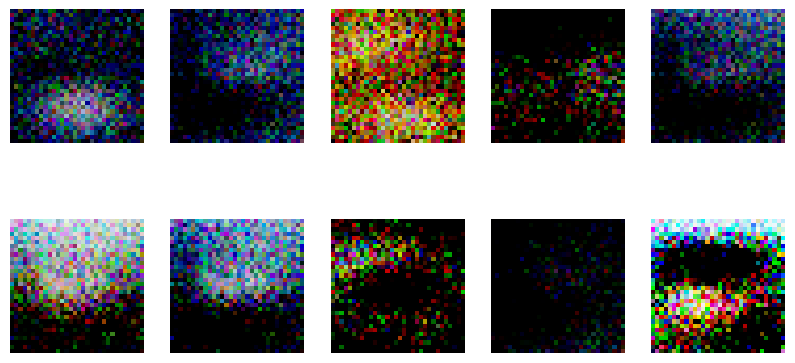

In [ ]:
def plot_generated_images(generator, z_dim, num_classes=10, rows=2, cols=5, device="cuda"):
    generator.eval()
    fig, axes = plt.subplots(rows, cols, figsize=(10, 5))

    for i in range(rows):
        for j in range(cols):
            z = torch.randn(1, z_dim).to(device)
            label = torch.tensor([i * cols + j]).to(device)
            with torch.no_grad():
                gen_img = generator(z, label)

            axes[i, j].imshow(gen_img[0].permute(1, 2, 0).cpu().numpy())
            axes[i, j].axis("off")

    plt.show()

plot_generated_images(generator, z_dim)


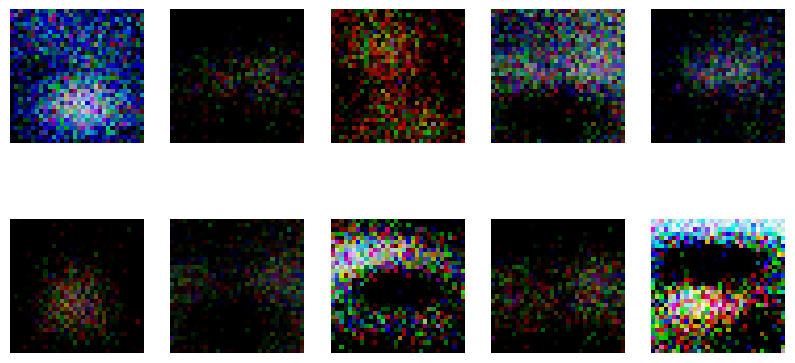

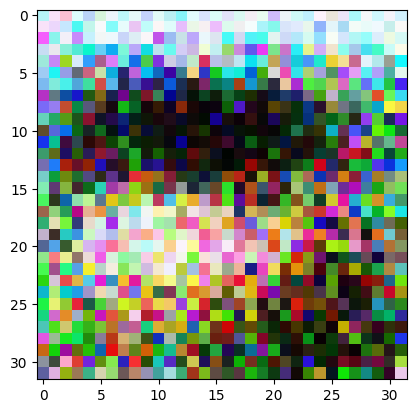

In [ ]:
def plot_generated_images(generator, z_dim, num_classes=10, rows=2, cols=5, device="cuda"):
    generator.eval()
    fig, axes = plt.subplots(rows, cols, figsize=(10, 5))

    for i in range(rows):
        for j in range(cols):
            z = torch.randn(1, z_dim).to(device)
            label = torch.tensor([i * cols + j]).to(device)
            with torch.no_grad():
                gen_img = generator(z, label)  # gen_img is created here

            axes[i, j].imshow(gen_img[0].permute(1, 2, 0).cpu().numpy())
            axes[i, j].axis("off")

    plt.show()
    return gen_img  # Return gen_img from the function


# Call the function and assign the returned value to gen_img
gen_img = plot_generated_images(generator, z_dim)

# ... (rest of the code)

# Scale the generated image from [-1, 1] to [0, 1] range
gen_img = (gen_img + 1) / 2  # Now the pixel values are in the range [0, 1]

# Visualize the generated image
import matplotlib.pyplot as plt
plt.imshow(gen_img[0].permute(1, 2, 0).cpu().detach().numpy())  # Display the first image in the batch
plt.show()